# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download Data

ในการจัดทำโครงงานครั้งนี้ ผู้จัดทำได้ใช้ชุดข้อมูล **ปริมาณฝนเชิงพื้นที่ รายเดือน รายจังหวัด** จาก **เว็บไซต์ชุดข้อมูลของสถาบันสารสนเทศทรัพยากรน้ำ (องค์การมหาชน)** (ฐานข้อมูลออนไลน์ที่ https://data.hii.or.th/dataset/
)  


*   แหล่งชุดข้อมูลเฉพาะ : [Spatial Rain - ข้อมูลฝนเชิงพื้นที่](https://data.hii.or.th/dataset/spatial-rain)
*   ไฟล์ข้อมูลดาวน์โหลด : [Google Drive](https://drive.google.com/file/d/1UxXxFlUvqYF6Gqtgb8ToNz7yuVUhOsvG/view?usp=sharing) หรือ ดาวน์โหลดจาก Resource metadata
*   ที่มาของชุดข้อมูล (Resource metadata) : https://data.hii.or.th/dataset/spatial-rain/resource/120aba77-b0a7-44c0-8043-91124dac45ed

*หมายเหตุ : ไฟล์ข้อมูลดาวน์โหลดใน Google Drive คือไฟล์ที่โหลดมาจาก Resource metadata ในวันที่ 30 กันยายน 2568*



In [ ]:
# โหลดข้อมูล
df = pd.read_csv("spatial-rain-hii.csv")

# ดูข้อมูล 5 แถวแรก
df.head()

,YEAR,MONTH,PROV_ID,PROV_T,MinRain,MaxRain,AvgRain
0,2018,1,10,กรุงเทพมหานคร,54.299999,257.230011,142.119137
1,2018,1,11,สมุทรปราการ,76.250000,256.100006,137.302046
2,2018,1,12,นนทบุรี,38.360001,161.470001,113.433771
3,2018,1,13,ปทุมธานี,51.439999,116.500000,82.901688
4,2018,1,14,พระนครศรีอยุธยา,8.850000,88.589996,39.960089


# Exploratory Data Analysis (EDA)

In [ ]:
# ดูจำนวนแถวและคอลัมน์
df.shape

(7084, 7)

In [ ]:
# ดูประเภทของข้อมูลแต่ละคอลัมน์
df.dtypes

,0
YEAR,int64
MONTH,int64
PROV_ID,int64
PROV_T,object
MinRain,float64
MaxRain,float64
AvgRain,float64


In [ ]:
# ตรวจสอบ Missing Value
df.isnull().sum()

,0
YEAR,0
MONTH,0
PROV_ID,0
PROV_T,0
MinRain,0
MaxRain,0
AvgRain,0


In [ ]:
# รวม YEAR + MONTH เป็น Year-Month
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')
df.head()

,YEAR,MONTH,PROV_ID,PROV_T,MinRain,MaxRain,AvgRain,DATE
0,2018,1,10,กรุงเทพมหานคร,54.299999,257.230011,142.119137,2018-01-01
1,2018,1,11,สมุทรปราการ,76.250000,256.100006,137.302046,2018-01-01
2,2018,1,12,นนทบุรี,38.360001,161.470001,113.433771,2018-01-01
3,2018,1,13,ปทุมธานี,51.439999,116.500000,82.901688,2018-01-01
4,2018,1,14,พระนครศรีอยุธยา,8.850000,88.589996,39.960089,2018-01-01


In [ ]:
# เพิ่มคอลัมน์ Month_Name
df['MONTH_NAME'] = df['DATE'].dt.month_name()
df.head()

,YEAR,MONTH,PROV_ID,PROV_T,MinRain,MaxRain,AvgRain,DATE,MONTH_NAME
0,2018,1,10,กรุงเทพมหานคร,54.299999,257.230011,142.119137,2018-01-01,January
1,2018,1,11,สมุทรปราการ,76.250000,256.100006,137.302046,2018-01-01,January
2,2018,1,12,นนทบุรี,38.360001,161.470001,113.433771,2018-01-01,January
3,2018,1,13,ปทุมธานี,51.439999,116.500000,82.901688,2018-01-01,January
4,2018,1,14,พระนครศรีอยุธยา,8.850000,88.589996,39.960089,2018-01-01,January


In [ ]:
# เพิ่มคอลัมน์ชื่อจังหวัดภาษาอังกฤษ
province_map = {
    "กรุงเทพมหานคร": "Bangkok",
    "กระบี่": "Krabi",
    "กาญจนบุรี": "Kanchanaburi",
    "กาฬสินธุ์": "Kalasin",
    "กำแพงเพชร": "Kamphaeng Phet",
    "ขอนแก่น": "Khon Kaen",
    "จันทบุรี": "Chanthaburi",
    "ฉะเชิงเทรา": "Chachoengsao",
    "ชลบุรี": "Chon Buri",
    "ชัยนาท": "Chai Nat",
    "ชัยภูมิ": "Chaiyaphum",
    "ชุมพร": "Chumphon",
    "เชียงราย": "Chiang Rai",
    "เชียงใหม่": "Chiang Mai",
    "ตรัง": "Trang",
    "ตราด": "Trat",
    "ตาก": "Tak",
    "นครนายก": "Nakhon Nayok",
    "นครปฐม": "Nakhon Pathom",
    "นครพนม": "Nakhon Phanom",
    "นครราชสีมา": "Nakhon Ratchasima",
    "นครศรีธรรมราช": "Nakhon Si Thammarat",
    "นครสวรรค์": "Nakhon Sawan",
    "นนทบุรี": "Nonthaburi",
    "นราธิวาส": "Narathiwat",
    "น่าน": "Nan",
    "บึงกาฬ": "Bueng Kan",
    "บุรีรัมย์": "Buri Ram",
    "ปทุมธานี": "Pathum Thani",
    "ประจวบคีรีขันธ์": "Prachuap Khiri Khan",
    "ปราจีนบุรี": "Prachin Buri",
    "ปัตตานี": "Pattani",
    "พระนครศรีอยุธยา": "Phra Nakhon Si Ayutthaya",
    "พังงา": "Phangnga",
    "พัทลุง": "Phatthalung",
    "พิจิตร": "Phichit",
    "พิษณุโลก": "Phitsanulok",
    "เพชรบุรี": "Phetchaburi",
    "เพชรบูรณ์": "Phetchabun",
    "แพร่": "Phrae",
    "ภูเก็ต": "Phuket",
    "มหาสารคาม": "Maha Sarakham",
    "มุกดาหาร": "Mukdahan",
    "แม่ฮ่องสอน": "Mae Hong Son",
    "ยโสธร": "Yasothon",
    "ยะลา": "Yala",
    "ร้อยเอ็ด": "Roi Et",
    "ระนอง": "Ranong",
    "ระยอง": "Rayong",
    "ราชบุรี": "Ratchaburi",
    "ลพบุรี": "Lop Buri",
    "ลำปาง": "Lampang",
    "ลำพูน": "Lamphun",
    "ศรีสะเกษ": "Si Sa Ket",
    "สกลนคร": "Sakon Nakhon",
    "สงขลา": "Songkhla",
    "สตูล": "Satun",
    "สมุทรปราการ": "Samut Prakan",
    "สมุทรสงคราม": "Samut Songkhram",
    "สมุทรสาคร": "Samut Sakhon",
    "สระแก้ว": "Sa Kaeo",
    "สระบุรี": "Saraburi",
    "สิงห์บุรี": "Sing Buri",
    "สุโขทัย": "Sukhothai",
    "สุพรรณบุรี": "Suphan Buri",
    "สุราษฎร์ธานี": "Surat Thani",
    "สุรินทร์": "Surin",
    "หนองคาย": "Nong Khai",
    "หนองบัวลำภู": "Nong Bua Lam Phu",
    "อ่างทอง": "Ang Thong",
    "อำนาจเจริญ": "Amnat Charoen",
    "อุดรธานี": "Udon Thani",
    "อุตรดิตถ์": "Uttaradit",
    "อุทัยธานี": "Uthai Thani",
    "อุบลราชธานี": "Ubon Ratchathani",
    "เลย": "Loei",
    "พะเยา": "Phayao"
}

# เพิ่มคอลัมน์ชื่อจังหวัดอังกฤษ
df["PROV_ENG"] = df["PROV_T"].map(province_map)


In [ ]:
# แยกภูมิภาค
region_map = {
    # ภาคเหนือ (North) – 9 จังหวัด
    "เชียงราย": "North", "น่าน": "North", "พะเยา": "North",
    "เชียงใหม่": "North", "แม่ฮ่องสอน": "North", "แพร่": "North",
    "ลำปาง": "North", "ลำพูน": "North", "อุตรดิตถ์": "North",

    # ภาคกลาง (Central) – 22 จังหวัด (รวม กทม.)
    "กรุงเทพมหานคร": "Central", "พิษณุโลก": "Central", "สุโขทัย": "Central",
    "เพชรบูรณ์": "Central", "พิจิตร": "Central", "กำแพงเพชร": "Central",
    "นครสวรรค์": "Central", "ลพบุรี": "Central", "ชัยนาท": "Central",
    "อุทัยธานี": "Central", "สิงห์บุรี": "Central", "อ่างทอง": "Central",
    "สระบุรี": "Central", "พระนครศรีอยุธยา": "Central", "สุพรรณบุรี": "Central",
    "นครนายก": "Central", "ปทุมธานี": "Central", "นนทบุรี": "Central",
    "นครปฐม": "Central", "สมุทรปราการ": "Central", "สมุทรสาคร": "Central",
    "สมุทรสงคราม": "Central",

    # ภาคตะวันออกเฉียงเหนือ (Northeast) – 19 จังหวัด
    "หนองคาย": "Northeast", "นครพนม": "Northeast", "สกลนคร": "Northeast",
    "อุดรธานี": "Northeast", "หนองบัวลำภู": "Northeast", "เลย": "Northeast",
    "มุกดาหาร": "Northeast", "กาฬสินธุ์": "Northeast", "ขอนแก่น": "Northeast",
    "อำนาจเจริญ": "Northeast", "ยโสธร": "Northeast", "ร้อยเอ็ด": "Northeast",
    "มหาสารคาม": "Northeast", "ชัยภูมิ": "Northeast", "นครราชสีมา": "Northeast",
    "บุรีรัมย์": "Northeast", "สุรินทร์": "Northeast", "ศรีสะเกษ": "Northeast",
    "อุบลราชธานี": "Northeast", "บึงกาฬ": "Northeast",

    # ภาคตะวันออก (East) – 7 จังหวัด
    "สระแก้ว": "East", "ปราจีนบุรี": "East", "ฉะเชิงเทรา": "East",
    "ชลบุรี": "East", "ระยอง": "East", "จันทบุรี": "East", "ตราด": "East",

    # ภาคตะวันตก (West) – 5 จังหวัด
    "ตาก": "West", "กาญจนบุรี": "West", "ราชบุรี": "West",
    "เพชรบุรี": "West", "ประจวบคีรีขันธ์": "West",

    # ภาคใต้ (South) – 14 จังหวัด
    "ชุมพร": "South", "ระนอง": "South", "สุราษฎร์ธานี": "South",
    "นครศรีธรรมราช": "South", "กระบี่": "South", "พังงา": "South",
    "ภูเก็ต": "South", "พัทลุง": "South", "ตรัง": "South",
    "ปัตตานี": "South", "สงขลา": "South", "สตูล": "South",
    "นราธิวาส": "South", "ยะลา": "South"
}

# เพิ่มคอลัมน์ REGION
df["REGION"] = df["PROV_T"].map(region_map)

# ตรวจสอบผลลัพธ์
df[["PROV_T", "REGION"]].head(20)

,PROV_T,REGION
0,กรุงเทพมหานคร,Central
1,สมุทรปราการ,Central
2,นนทบุรี,Central
3,ปทุมธานี,Central
4,พระนครศรีอยุธยา,Central
5,อ่างทอง,Central
6,ลพบุรี,Central
7,สิงห์บุรี,Central
8,ชัยนาท,Central
9,สระบุรี,Central


Correlation matrix:
           MinRain   MaxRain   AvgRain
MinRain  1.000000  0.844388  0.949269
MaxRain  0.844388  1.000000  0.946705
AvgRain  0.949269  0.946705  1.000000


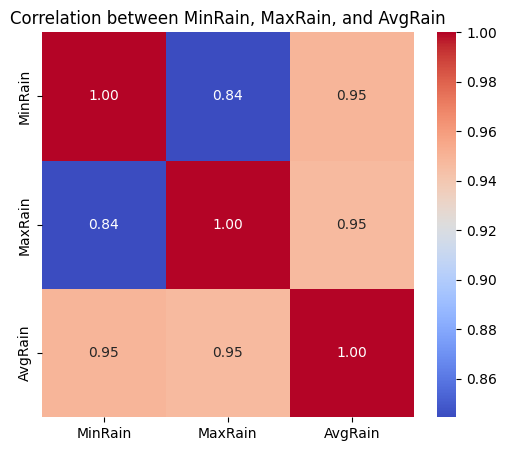

In [ ]:
# ดูความสัมพันธ์ของ MinRain, MaxRain, AvgRain

# Select relevant columns
rain_cols = ["MinRain", "MaxRain", "AvgRain"]

# Compute correlation
corr = df[rain_cols].corr()

print("Correlation matrix:\n", corr)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between MinRain, MaxRain, and AvgRain")
plt.show()

จากการวิเคราะห์ correlation พบว่า ค่า AvgRain มีความสัมพันธ์เชิงบวกสูงกับทั้ง MinRain และ MaxRain (0.95) ดังนั้นในการวิเคราะห์เชิงพื้นที่และเวลา สามารถเลือกใช้ AvgRain เป็นตัวแทนได้ อย่างไรก็ตาม ความแตกต่างระหว่าง MaxRain และ MinRain (Rain Variability) ยังมีความสำคัญต่อการทำความเข้าใจความแปรปรวนของฝนในแต่ละจังหวัด

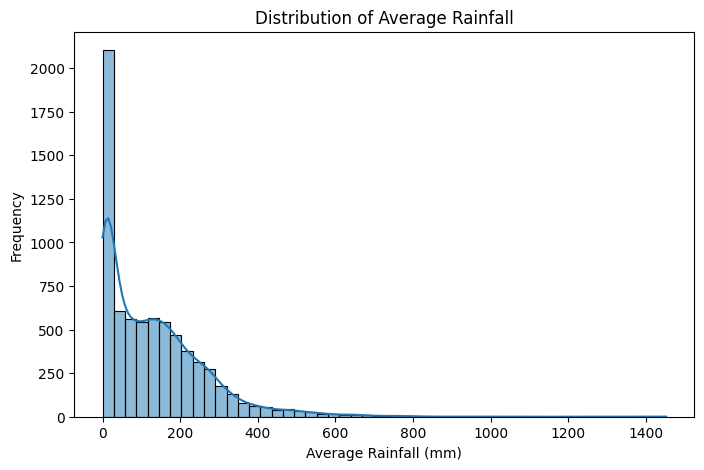

In [ ]:
# ดูการกระจายตัวของปริมาณน้ำฝนเฉลี่ยทั่วประเทศ
plt.figure(figsize=(8,5))
sns.histplot(df['AvgRain'], bins=50, kde=True)
plt.title("Distribution of Average Rainfall")
plt.xlabel("Average Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

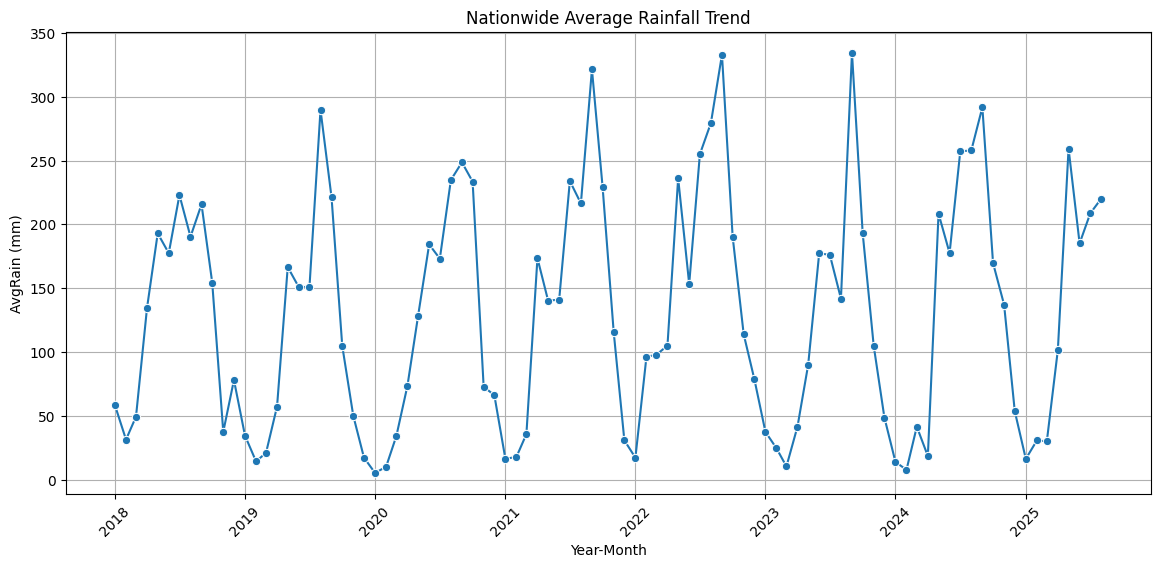

In [ ]:
# ดูแนวโน้มทั่วประเทศ (ค่าเฉลี่ย รายปี/เดือน)
nationwide_monthly = df.groupby('DATE')['AvgRain'].mean().reset_index()
plt.figure(figsize=(14,6))
sns.lineplot(data=nationwide_monthly, x='DATE', y='AvgRain', marker='o')
plt.title("Nationwide Average Rainfall Trend")
plt.xlabel("Year-Month")
plt.ylabel("AvgRain (mm)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# หาค่าฝนเฉลี่ยในแต่ละปี
yearly_avg = df.groupby('YEAR')['AvgRain'].mean().reset_index()
yearly_avg

,YEAR,AvgRain
0,2018,128.615111
1,2019,106.598543
2,2020,122.111561
3,2021,139.391918
4,2022,163.057309
5,2023,115.083193
6,2024,136.277372
7,2025,131.576259


Text(0, 0.5, 'AvgRain (mm)')

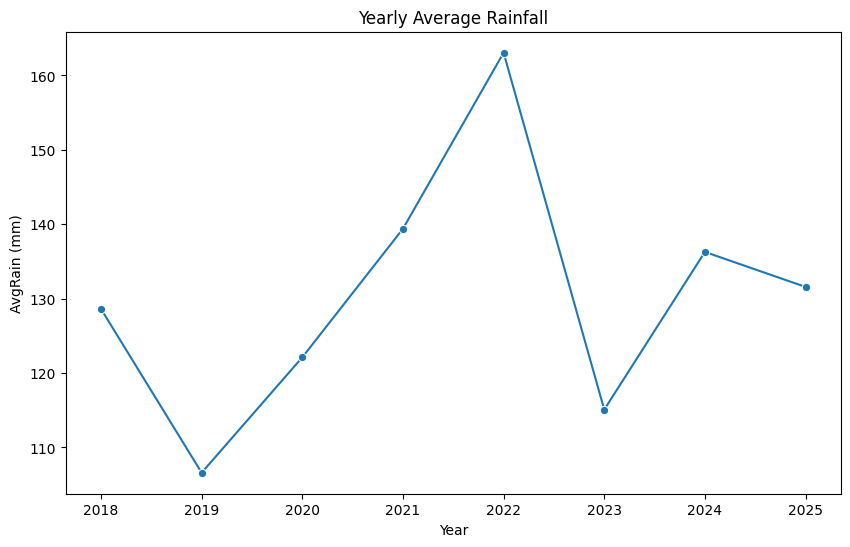

In [ ]:
# กราฟค่าฝนเฉลี่ยในแต่ละปี
plt.figure(figsize=(10,6))
sns.lineplot(data=yearly_avg, x='YEAR', y='AvgRain', marker='o')
plt.title("Yearly Average Rainfall")
plt.xlabel("Year")
plt.ylabel("AvgRain (mm)")

/tmp/ipython-input-3808457964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='AvgRain', y='PROV_ENG', palette='Blues_r')


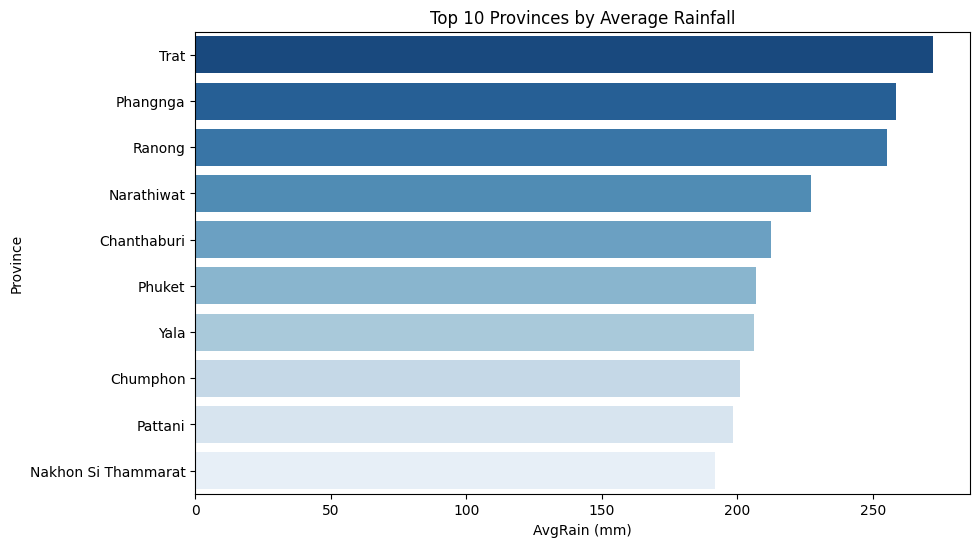

/tmp/ipython-input-3808457964.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x='AvgRain', y='PROV_ENG', palette='Reds_r')


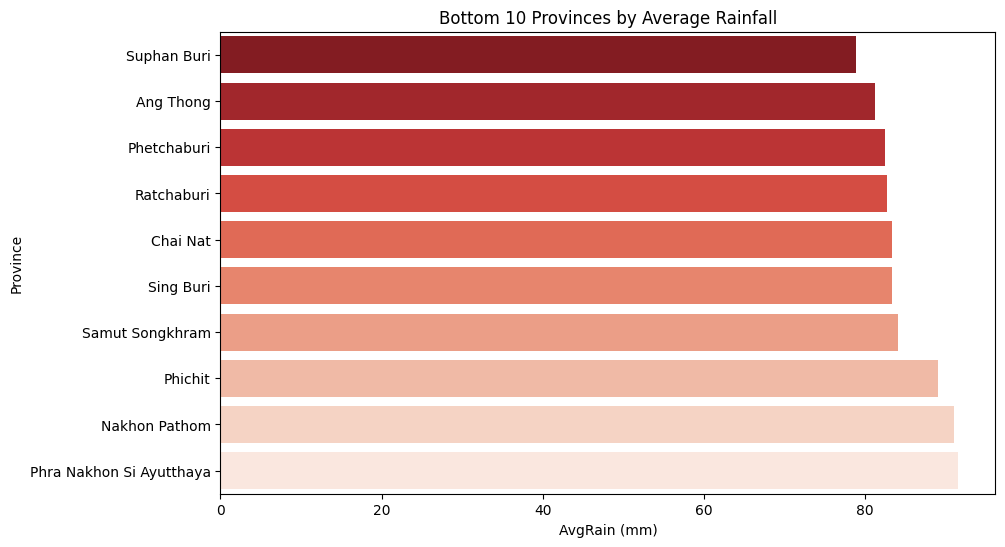

In [ ]:
# ปริมาณน้ำฝนเฉลี่ย 10 อันดับแรก และ 10 อันดับสุดท้าย
province_avg = df.groupby('PROV_ENG')['AvgRain'].mean().reset_index()

top10 = province_avg.sort_values('AvgRain', ascending=False).head(10)
bottom10 = province_avg.sort_values('AvgRain', ascending=True).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='AvgRain', y='PROV_ENG', palette='Blues_r')
plt.title("Top 10 Provinces by Average Rainfall")
plt.xlabel("AvgRain (mm)")
plt.ylabel("Province")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=bottom10, x='AvgRain', y='PROV_ENG', palette='Reds_r')
plt.title("Bottom 10 Provinces by Average Rainfall")
plt.xlabel("AvgRain (mm)")
plt.ylabel("Province")
plt.show()

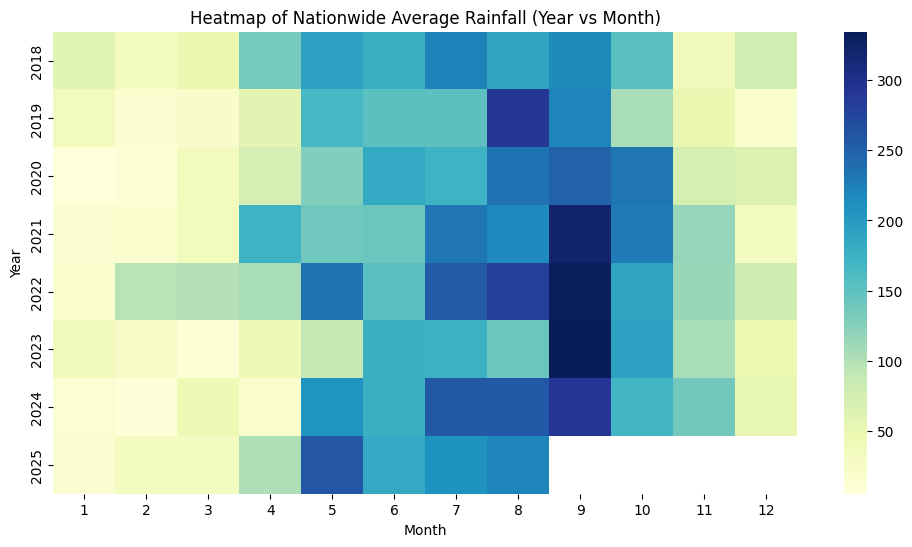

In [ ]:
heatmap_data = df.groupby(['YEAR','MONTH'])['AvgRain'].mean().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False)
plt.title("Heatmap of Nationwide Average Rainfall (Year vs Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

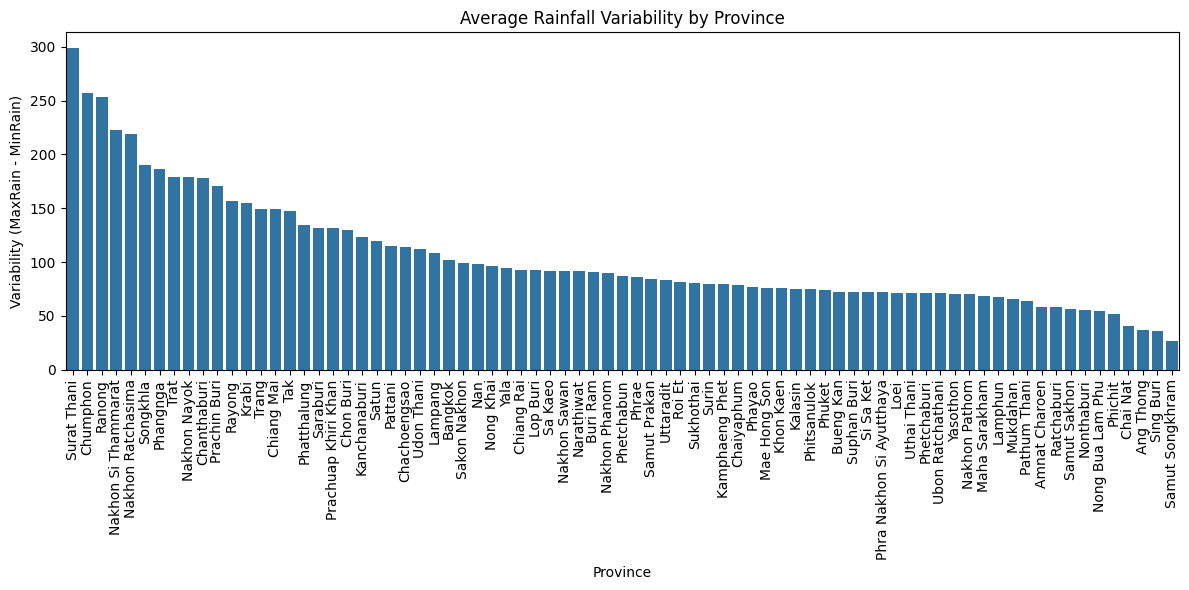

In [ ]:
# ความแปรปรวนของปริมาณน้ำฝนในแต่ละจังหวัด
df['Variability'] = df['MaxRain'] - df['MinRain']
province_var = df.groupby('PROV_ENG')['Variability'].mean().reset_index()
province_var = province_var.sort_values('Variability', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=province_var, x='PROV_ENG', y='Variability')
plt.title("Average Rainfall Variability by Province") # เพิ่มชื่อกราฟให้ชัดเจนขึ้น
plt.xlabel("Province") # เพิ่มชื่อแกน X
plt.ylabel("Variability (MaxRain - MinRain)") # เพิ่มชื่อแกน Y
plt.xticks(rotation=90) # หมุนป้ายชื่อแกน X เพื่อให้อ่านง่ายขึ้น
plt.tight_layout() # ปรับ layout เพื่อไม่ให้ป้ายชื่อทับซ้อนกัน
plt.show()

In [ ]:
print("Province with highest avg rainfall:", province_avg.loc[province_avg['AvgRain'].idxmax(), 'PROV_ENG'])
print("Province with lowest avg rainfall:", province_avg.loc[province_avg['AvgRain'].idxmin(), 'PROV_ENG'])

print("Province with highest variability:", province_var.loc[province_var['Variability'].idxmax(), 'PROV_ENG'])
print("Province with lowest variability:", province_var.loc[province_var['Variability'].idxmin(), 'PROV_ENG'])

print("Year with highest avg rainfall:",
      df.groupby('YEAR')['AvgRain'].mean().idxmax())
print("Year with lowest avg rainfall:",
      df.groupby('YEAR')['AvgRain'].mean().idxmin())

Province with highest avg rainfall: Trat
Province with lowest avg rainfall: Suphan Buri
Province with highest variability: Surat Thani
Province with lowest variability: Samut Songkhram
Year with highest avg rainfall: 2022
Year with lowest avg rainfall: 2019


In [ ]:
# ดู Correlation ของแต่ละจังหวัดในแต่ละภาค
region_avg = df.groupby(['REGION', 'PROV_ENG'])['AvgRain'].mean().reset_index()

# Calculate correlation matrix for each region
correlation_matrices = {}
for region in df['REGION'].unique():
    if pd.notnull(region): # Skip NaN region
        region_data = df[df['REGION'] == region].pivot_table(index='DATE', columns='PROV_ENG', values='AvgRain')
        correlation_matrices[region] = region_data.corr()



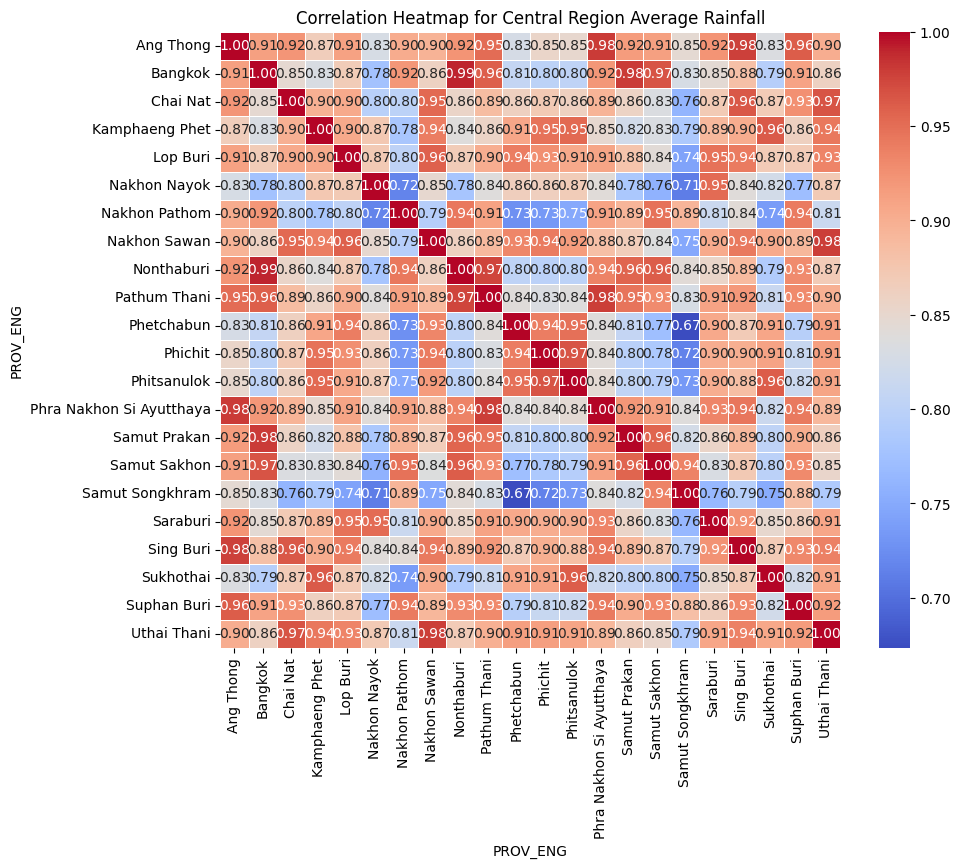

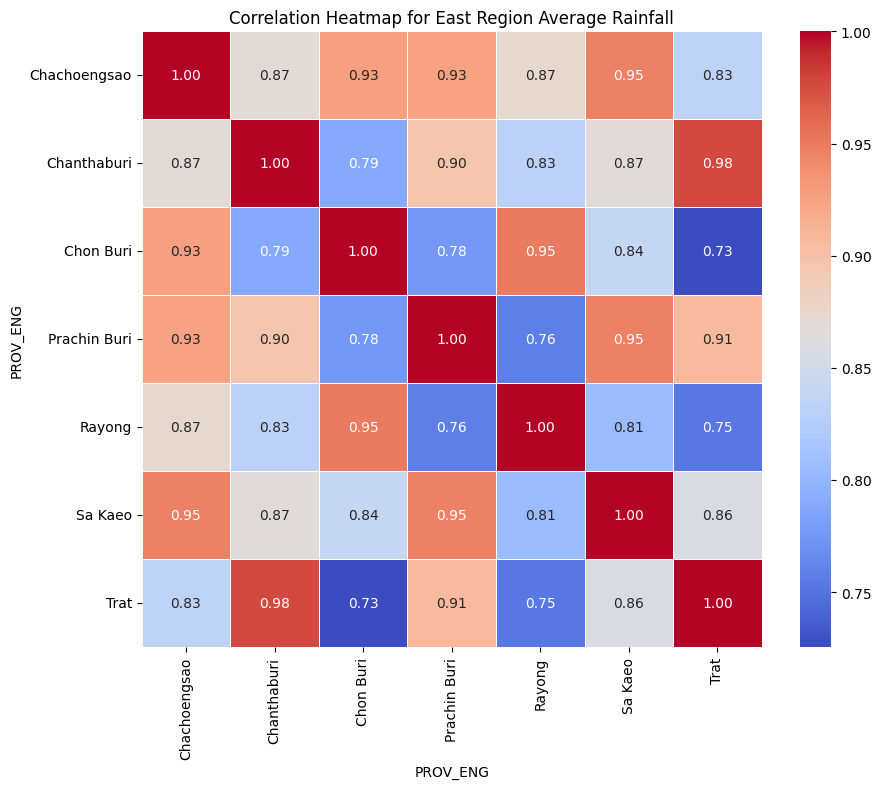

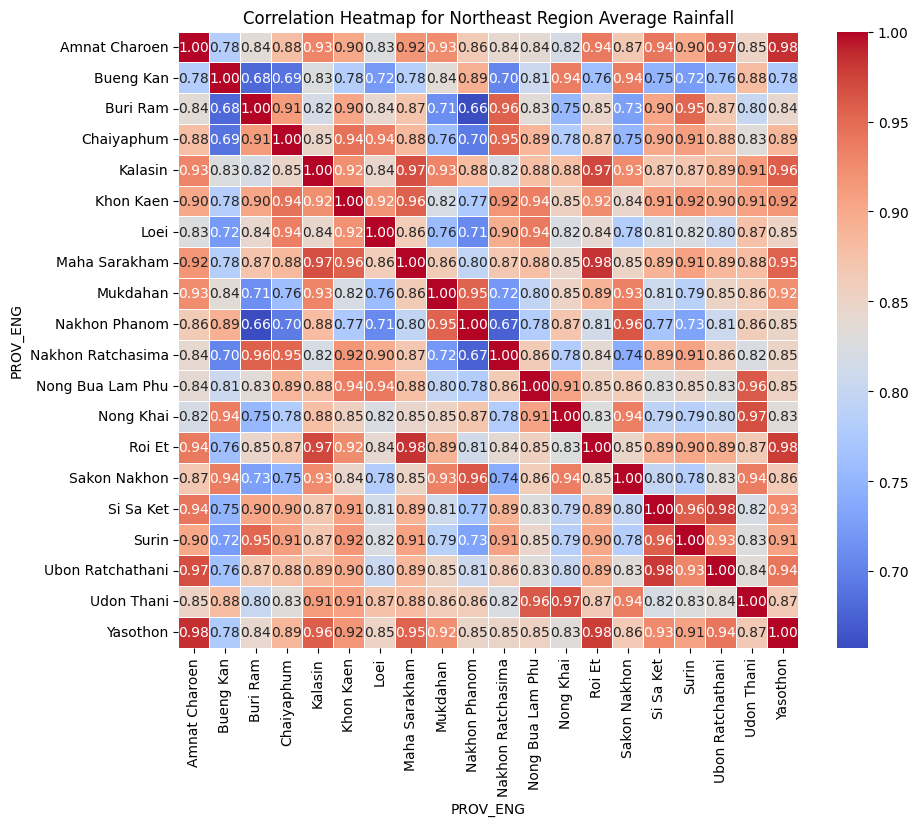

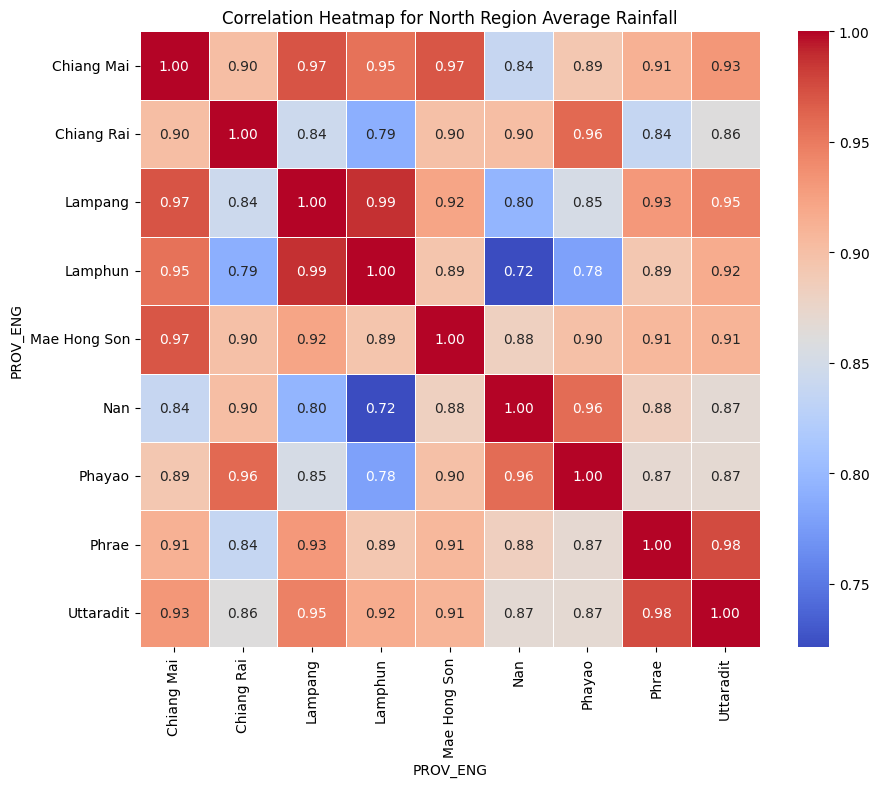

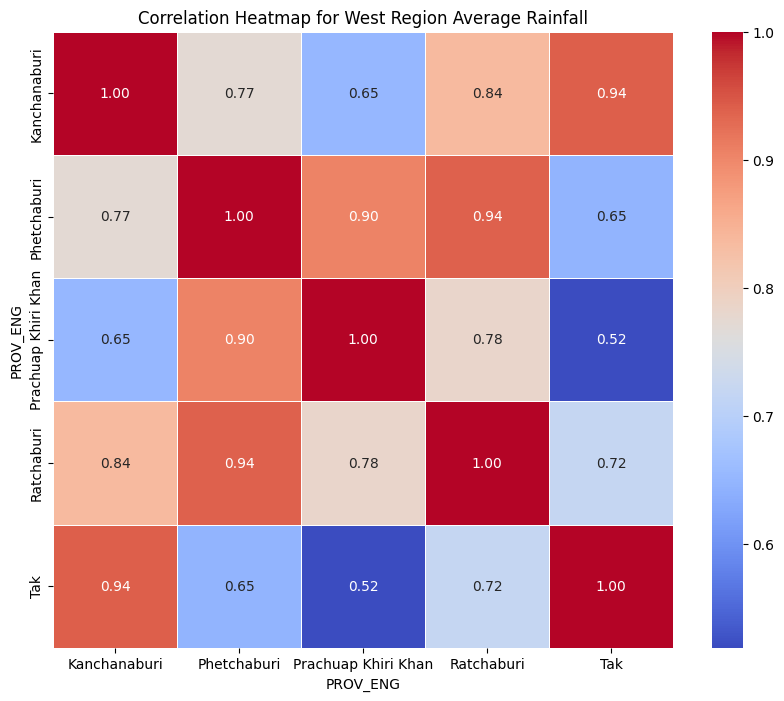

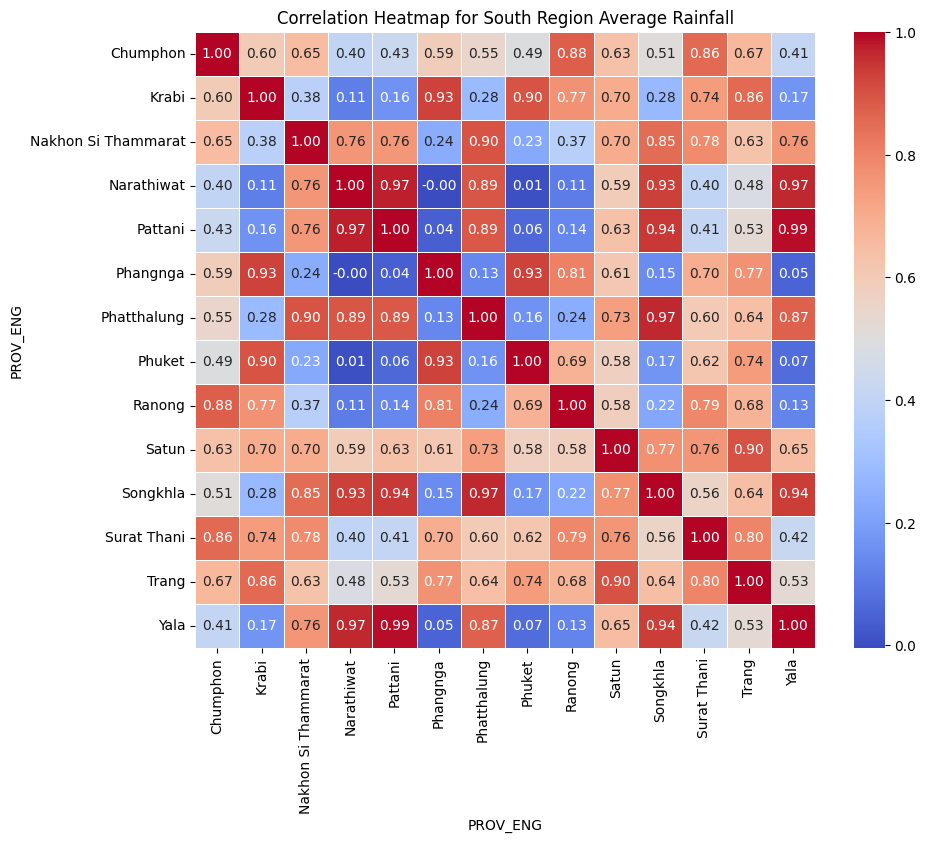

In [ ]:
# ดู Correlation ของแต่ละจังหวัดในแต่ละภูมิภาค

for region, correlation_matrix in correlation_matrices.items():
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(f'Correlation Heatmap for {region} Region Average Rainfall')
    plt.show()

In [ ]:
# ปริมาณน้ำฝนเฉลี่ยของแต่ละภาค
region_avg = df.groupby('REGION')['AvgRain'].mean().reset_index()
region_avg

,REGION,AvgRain
0,Central,100.005801
1,East,161.191256
2,North,107.649772
3,Northeast,121.758804
4,South,200.930050
5,West,97.288476


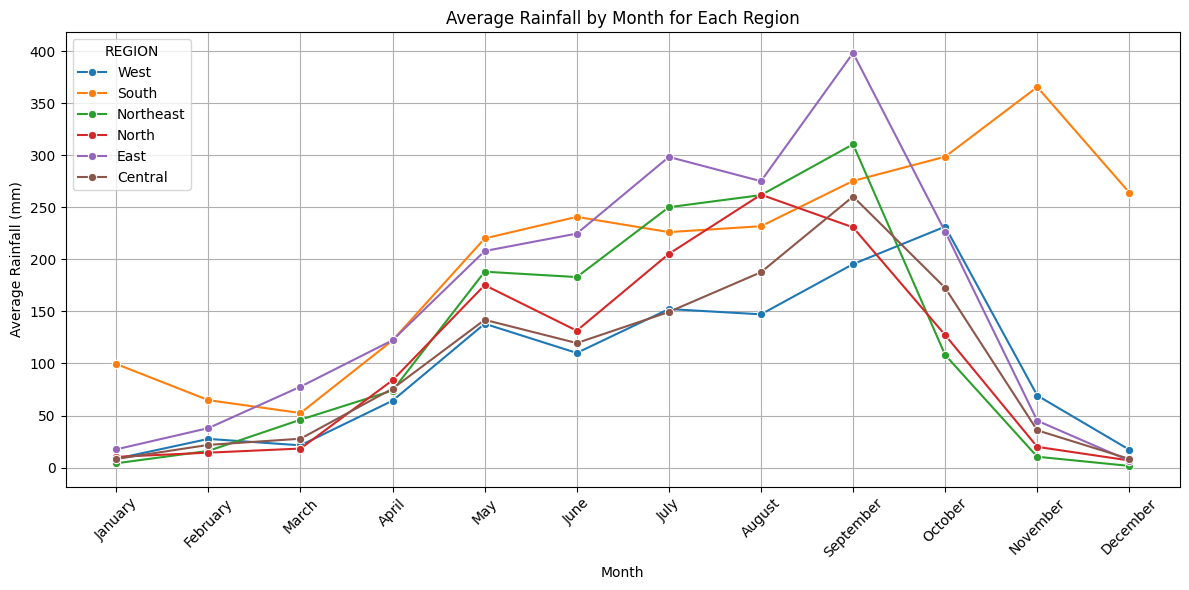

In [ ]:
# กราฟปริมาณน้ำฝนเฉลี่ยแต่ละเดือนในแต่ละภาค
monthly_avg = df.groupby(['MONTH_NAME', 'REGION'])['AvgRain'].mean().reset_index()

# Define the correct order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert MONTH_NAME to a categorical type with the correct order
monthly_avg['MONTH_NAME'] = pd.Categorical(monthly_avg['MONTH_NAME'], categories=month_order, ordered=True)

# Sort the DataFrame by MONTH_NAME for correct plotting order
monthly_avg = monthly_avg.sort_values('MONTH_NAME')

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, x='MONTH_NAME', y='AvgRain', hue='REGION', marker='o')
plt.title("Average Rainfall by Month for Each Region")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

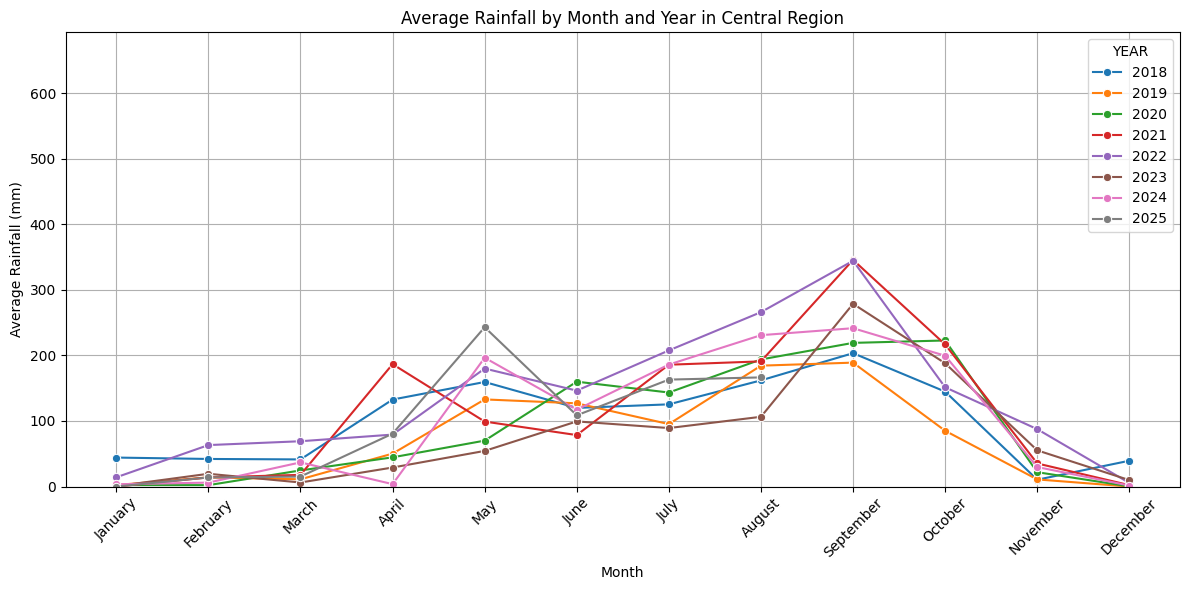

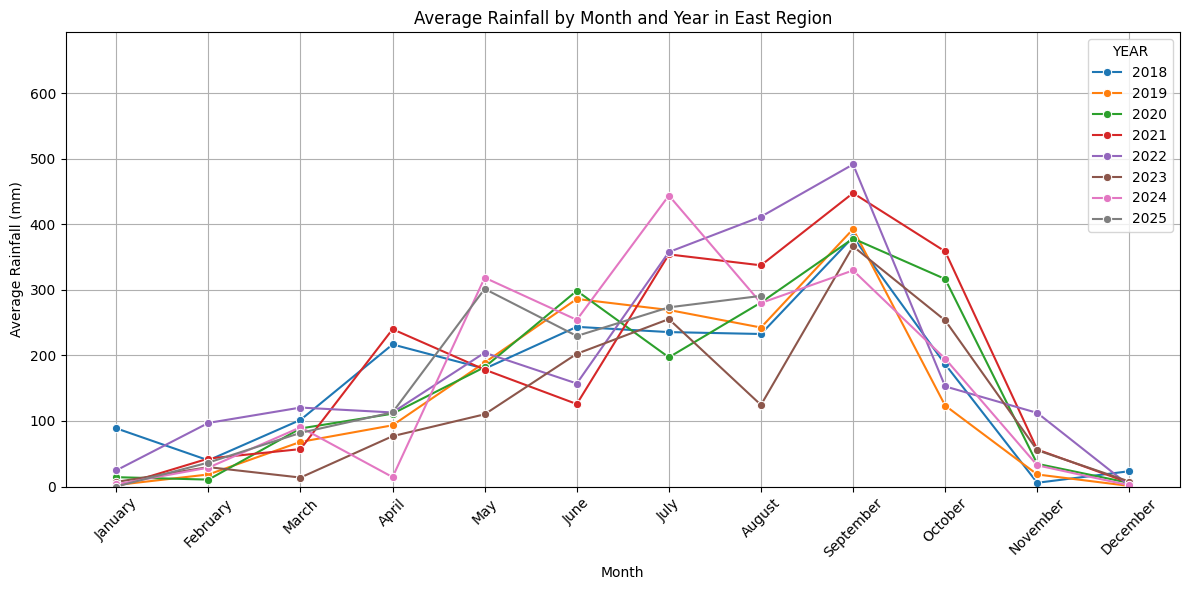

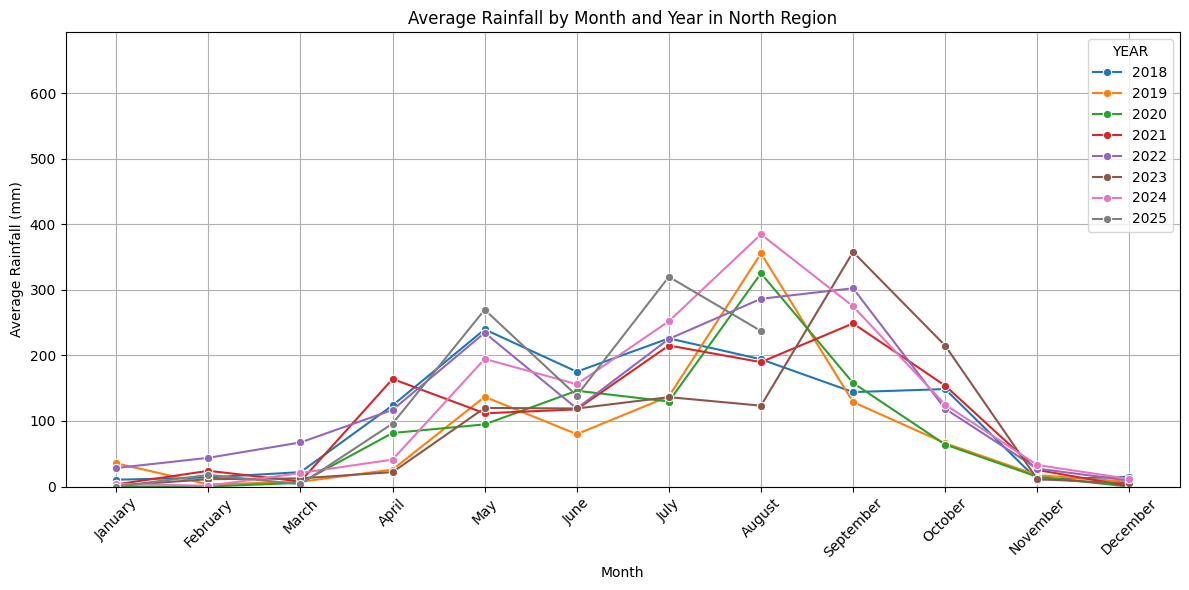

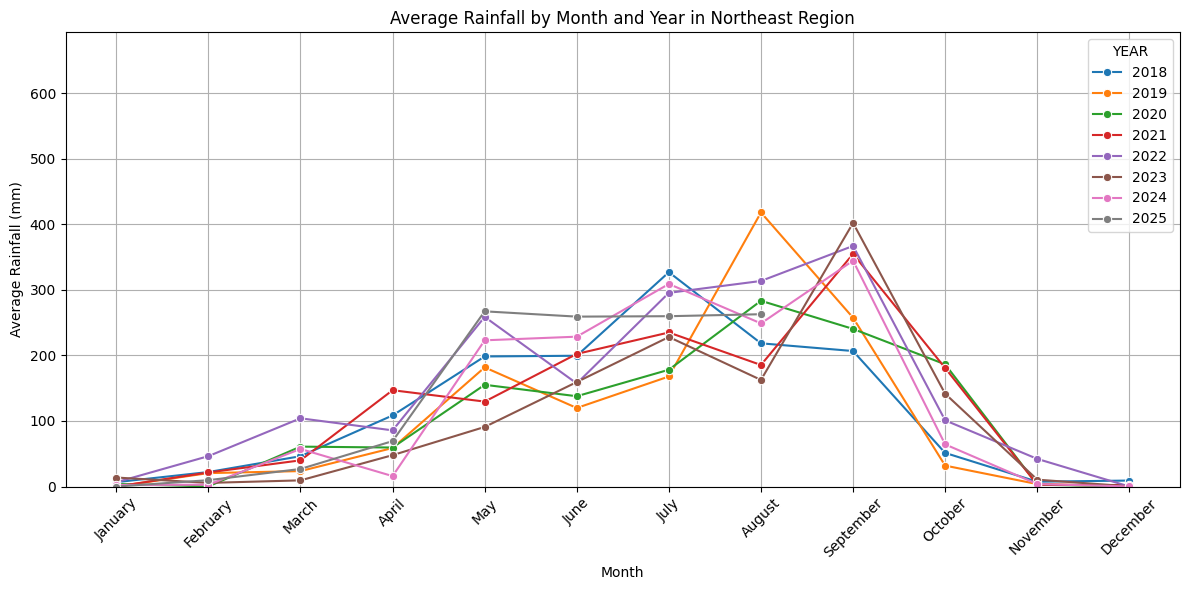

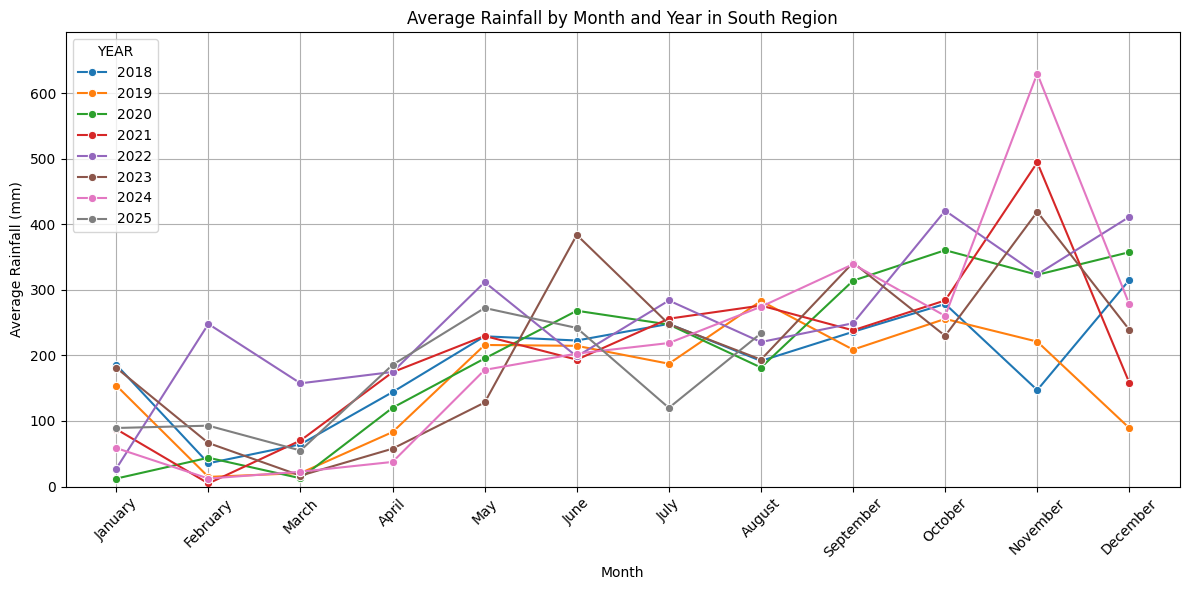

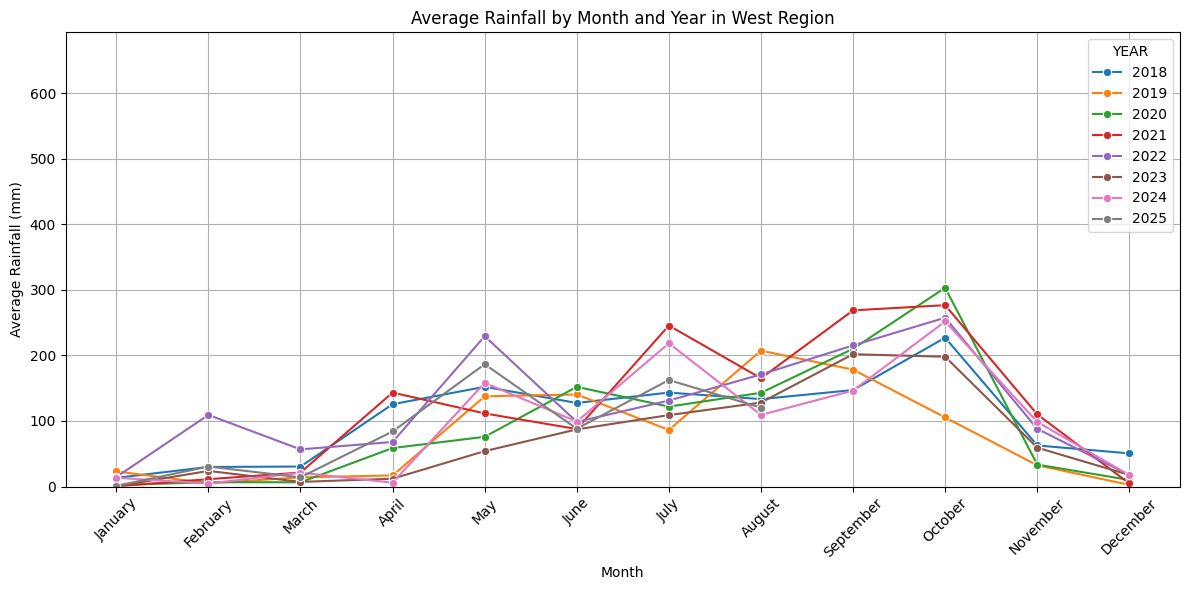

In [ ]:
# กราฟปริมาณน้ำฝนเฉลี่ยแต่ละเดือนในแต่ละปีแยกตามภาค

# Group by year, month name, and region to get the average rainfall
yearly_monthly_avg_region = df.groupby(['YEAR', 'MONTH_NAME', 'REGION'])['AvgRain'].mean().reset_index()

# Define the correct order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert MONTH_NAME to a categorical type with the correct order
yearly_monthly_avg_region['MONTH_NAME'] = pd.Categorical(yearly_monthly_avg_region['MONTH_NAME'], categories=month_order, ordered=True)

# Iterate through each region and create a line plot
regions = yearly_monthly_avg_region['REGION'].unique()

# Calculate the global maximum of AvgRain across all regions and years
global_max_avg_rain = yearly_monthly_avg_region['AvgRain'].max()

for region in regions:
    if pd.notnull(region): # Skip NaN region
        region_data = yearly_monthly_avg_region[yearly_monthly_avg_region['REGION'] == region].sort_values(['YEAR', 'MONTH_NAME'])

        plt.figure(figsize=(12, 6))
        # Use a different color palette, such as 'tab10' or 'viridis' to distinguish years
        sns.lineplot(data=region_data, x='MONTH_NAME', y='AvgRain', hue='YEAR', marker='o', palette='tab10')
        plt.title(f'Average Rainfall by Month and Year in {region} Region')
        plt.xlabel("Month")
        plt.ylabel("Average Rainfall (mm)")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.ylim(0, global_max_avg_rain * 1.1) # Set the y-axis limit to the global maximum + 10% buffer
        plt.tight_layout()
        plt.show()

/tmp/ipython-input-799668094.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='AvgRain', y='PROV_ENG', palette='viridis')


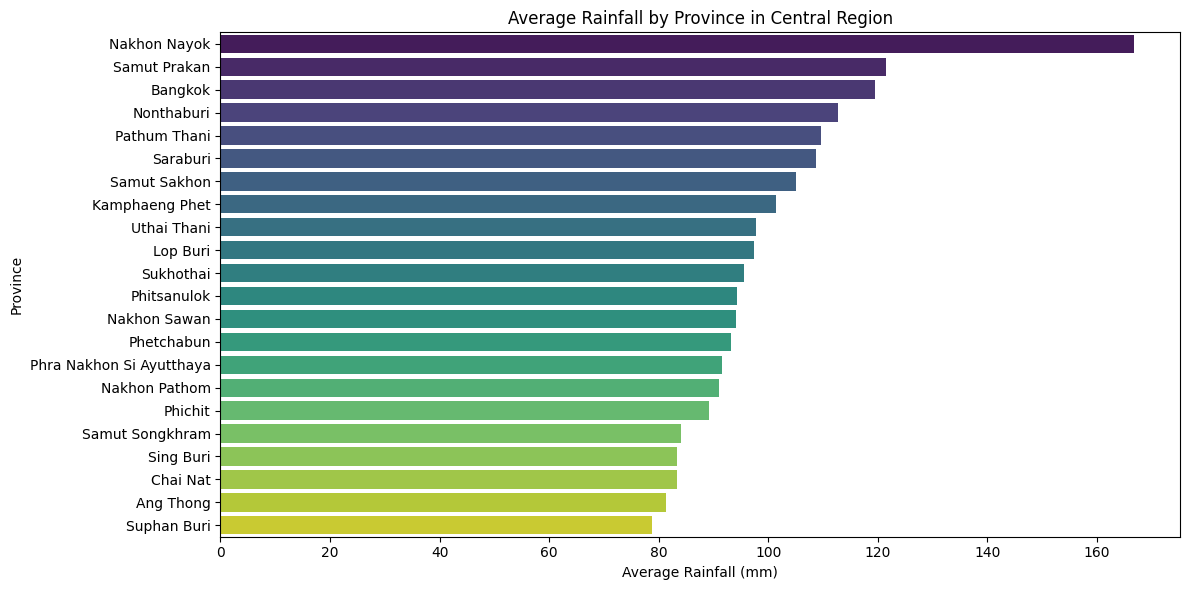

/tmp/ipython-input-799668094.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='AvgRain', y='PROV_ENG', palette='viridis')


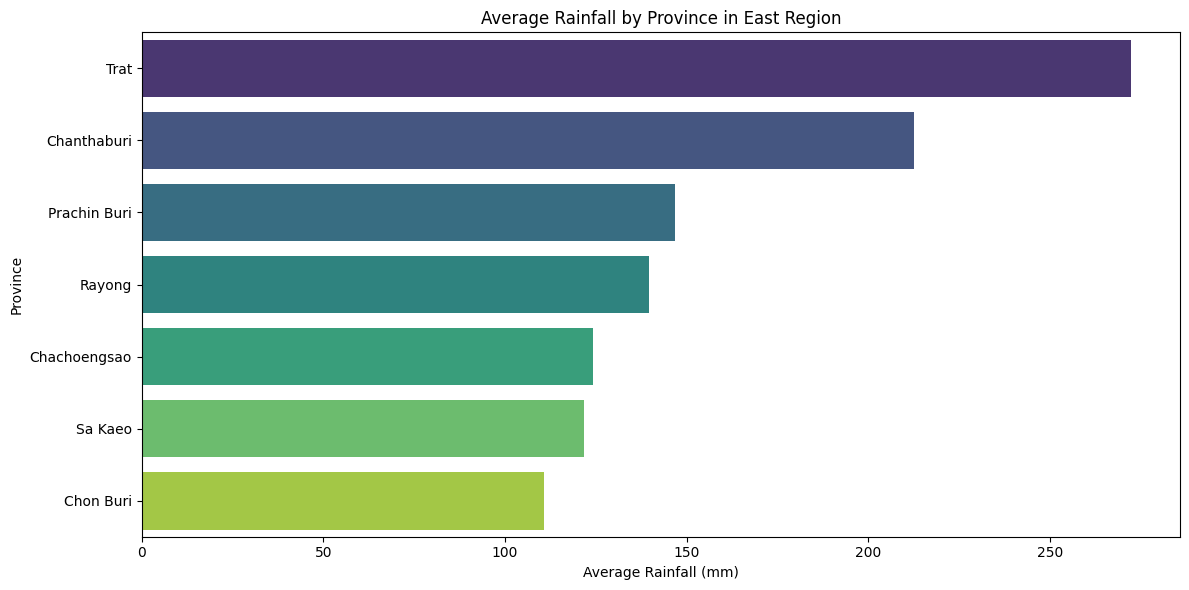

/tmp/ipython-input-799668094.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='AvgRain', y='PROV_ENG', palette='viridis')


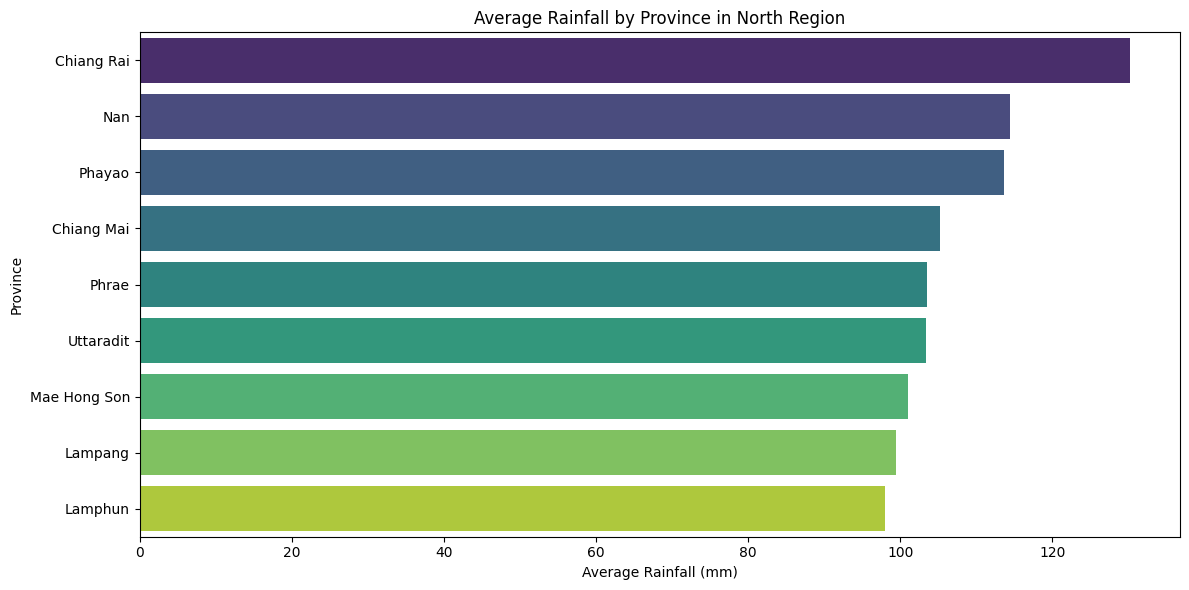

/tmp/ipython-input-799668094.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='AvgRain', y='PROV_ENG', palette='viridis')


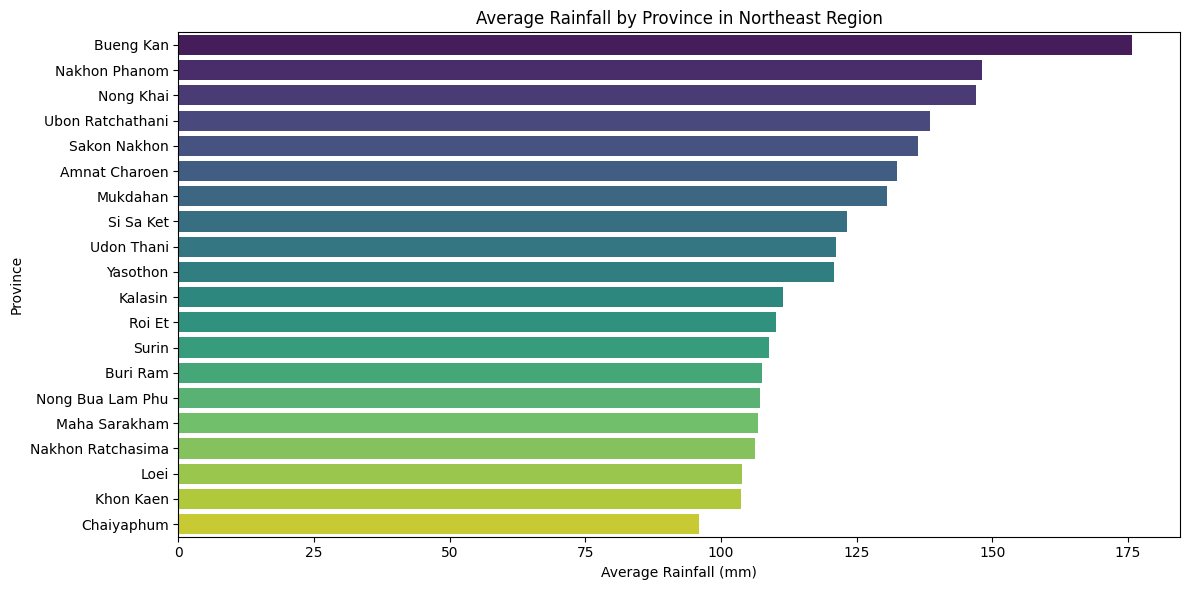

/tmp/ipython-input-799668094.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='AvgRain', y='PROV_ENG', palette='viridis')


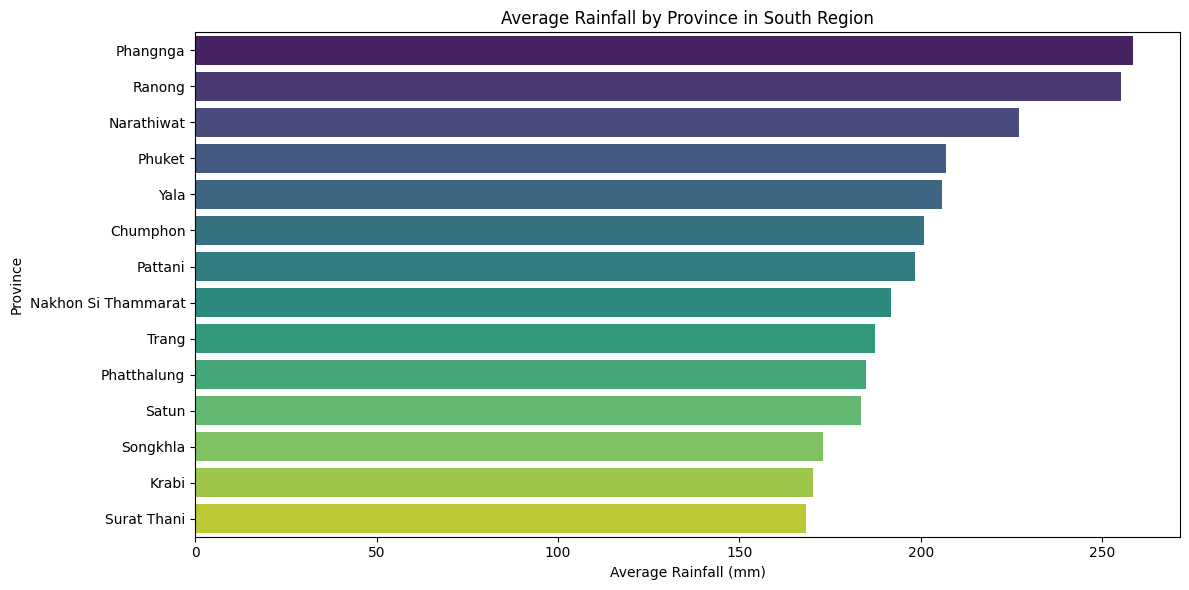

/tmp/ipython-input-799668094.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='AvgRain', y='PROV_ENG', palette='viridis')


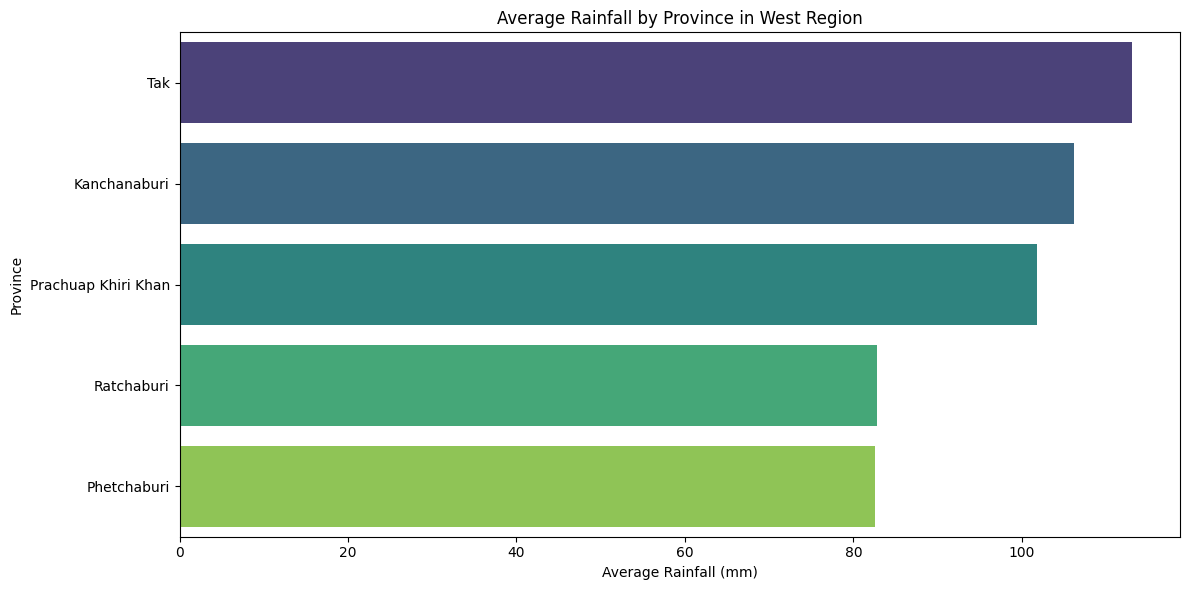

In [ ]:
# ดูว่าในแต่ละภาคจังหวัดไหนมีปริมาณฝนเฉลี่ยมากสุด น้อยสุด

# Group by region and province to get the average rainfall per province
province_avg_region = df.groupby(['REGION', 'PROV_ENG'])['AvgRain'].mean().reset_index()

# Iterate through each region and create a bar plot
regions = province_avg_region['REGION'].unique()

for region in regions:
    if pd.notnull(region): # Skip NaN region
        region_data = province_avg_region[province_avg_region['REGION'] == region].sort_values('AvgRain', ascending=False)

        plt.figure(figsize=(12, 6))
        sns.barplot(data=region_data, x='AvgRain', y='PROV_ENG', palette='viridis')
        plt.title(f'Average Rainfall by Province in {region} Region')
        plt.xlabel("Average Rainfall (mm)")
        plt.ylabel("Province")
        plt.tight_layout()
        plt.show()

/tmp/ipython-input-3118447640.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_variability, x='REGION', y='Variability', palette='viridis')


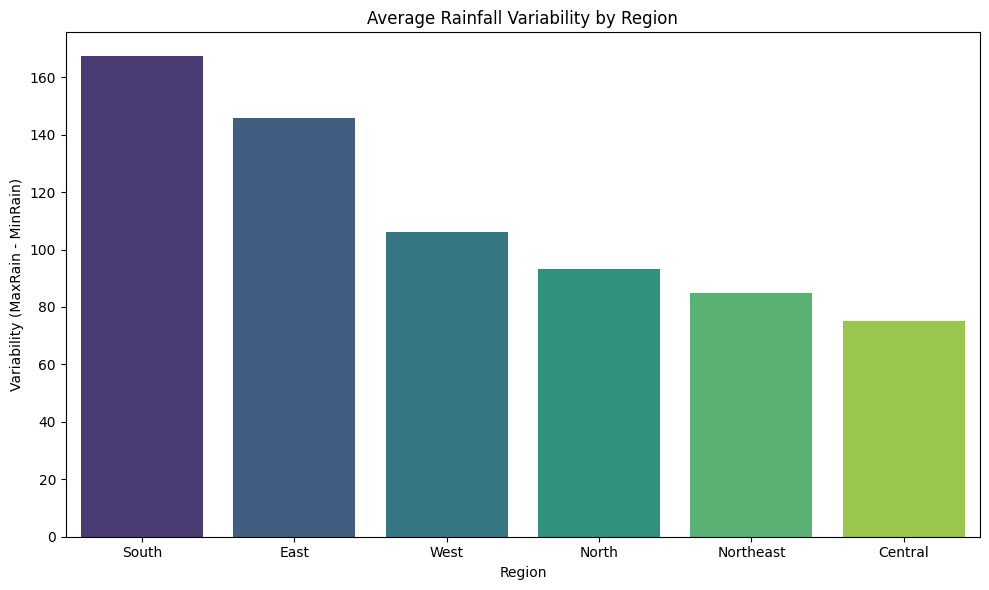

In [ ]:
# ดูความแปรปรวนของปริมาณน้ำฝนเฉลี่ยโดยเปรียบเทียบในแต่ละภาค
region_variability = df.groupby('REGION')['Variability'].mean().reset_index()
region_variability = region_variability.sort_values('Variability', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=region_variability, x='REGION', y='Variability', palette='viridis')
plt.title("Average Rainfall Variability by Region")
plt.xlabel("Region")
plt.ylabel("Variability (MaxRain - MinRain)")
plt.tight_layout()
plt.show()

In [ ]:
region_variability

,REGION,Variability
4,South,167.275117
1,East,145.879922
5,West,106.243674
2,North,93.129010
3,Northeast,84.988734
0,Central,75.208953


In [ ]:
df[['AvgRain', 'Variability']].corr()

,AvgRain,Variability
AvgRain,1.000000,0.721893
Variability,0.721893,1.000000


/tmp/ipython-input-3728211731.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='Variability', y='PROV_ENG', palette='viridis')


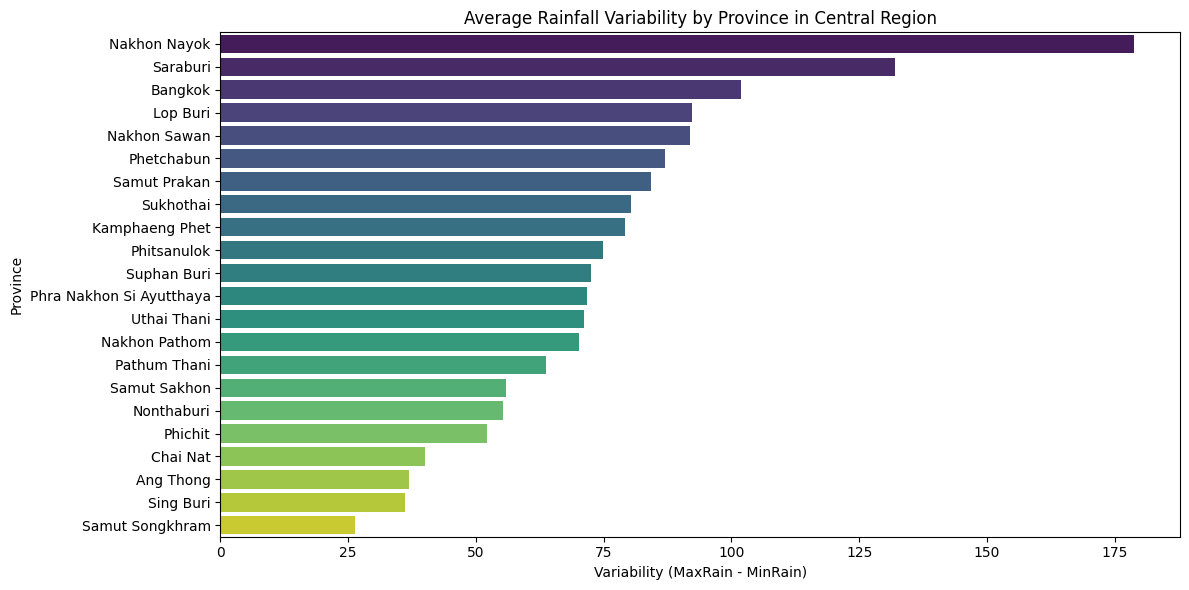

/tmp/ipython-input-3728211731.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='Variability', y='PROV_ENG', palette='viridis')


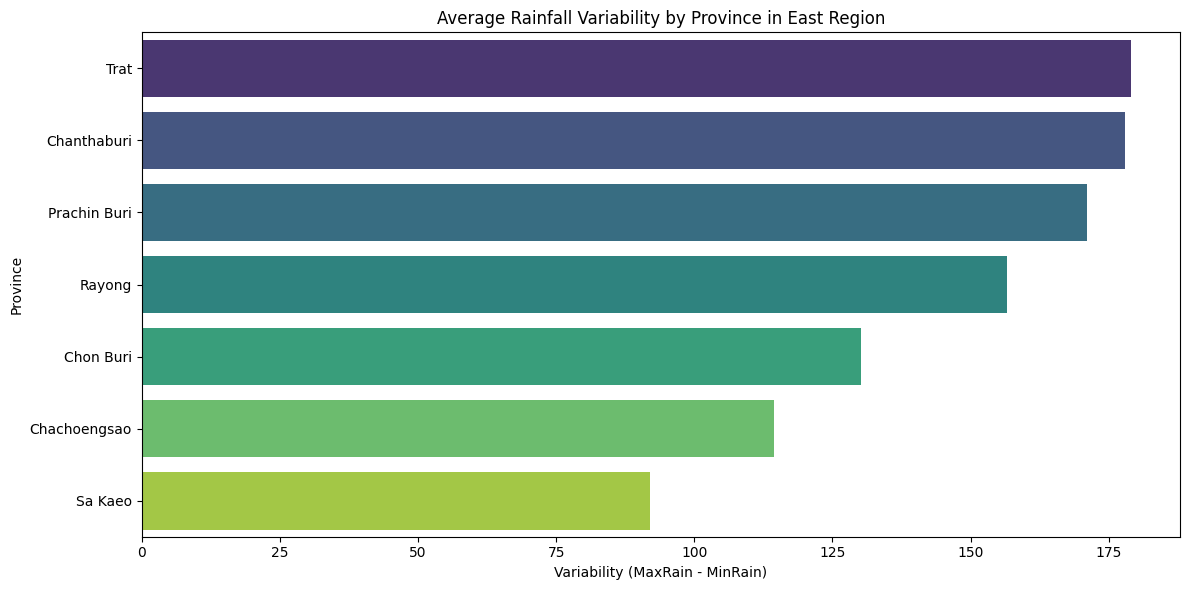

/tmp/ipython-input-3728211731.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='Variability', y='PROV_ENG', palette='viridis')


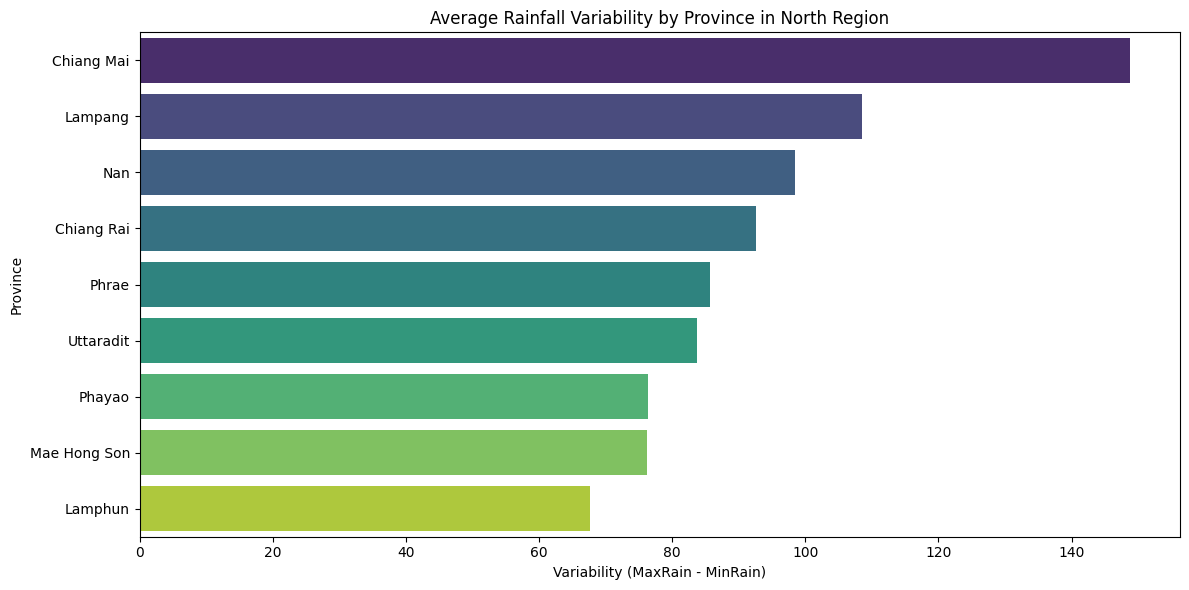

/tmp/ipython-input-3728211731.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='Variability', y='PROV_ENG', palette='viridis')


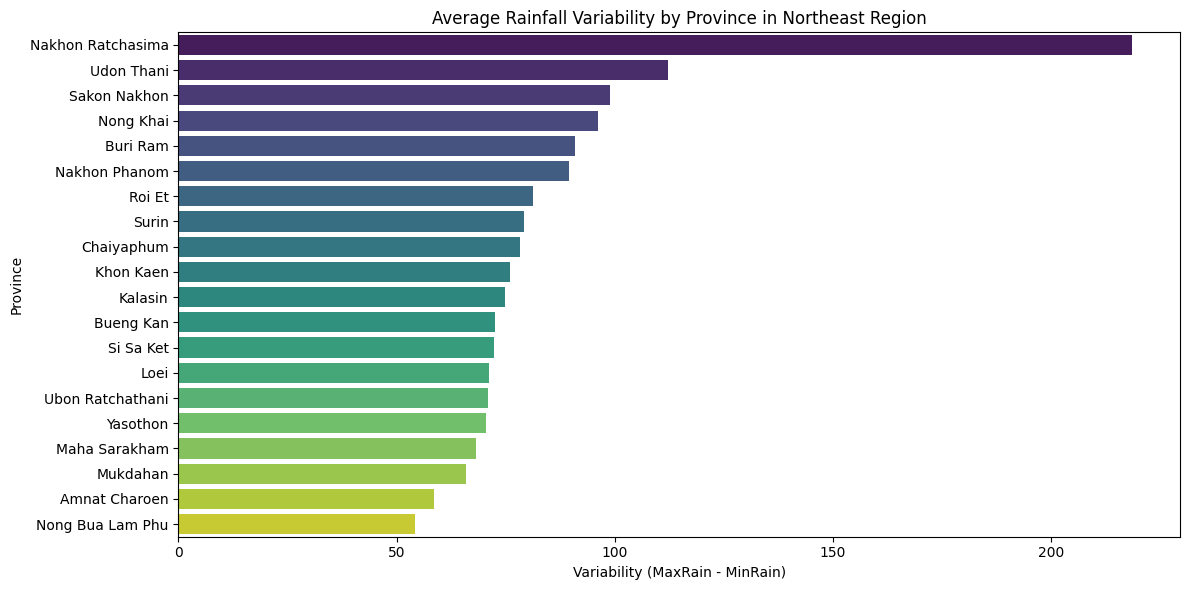

/tmp/ipython-input-3728211731.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='Variability', y='PROV_ENG', palette='viridis')


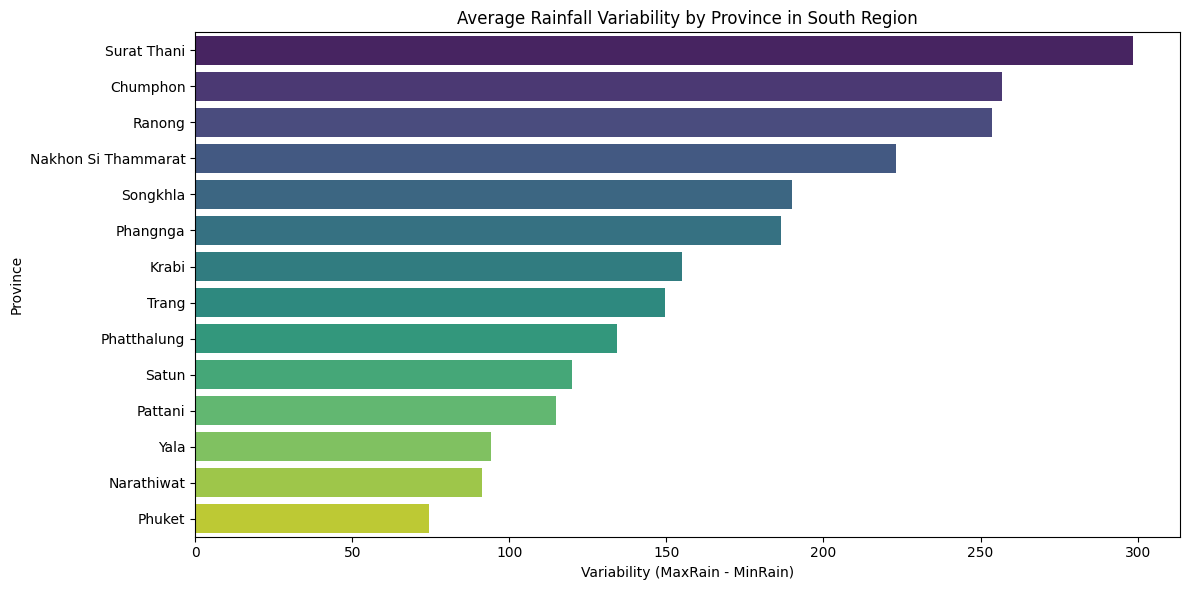

/tmp/ipython-input-3728211731.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='Variability', y='PROV_ENG', palette='viridis')


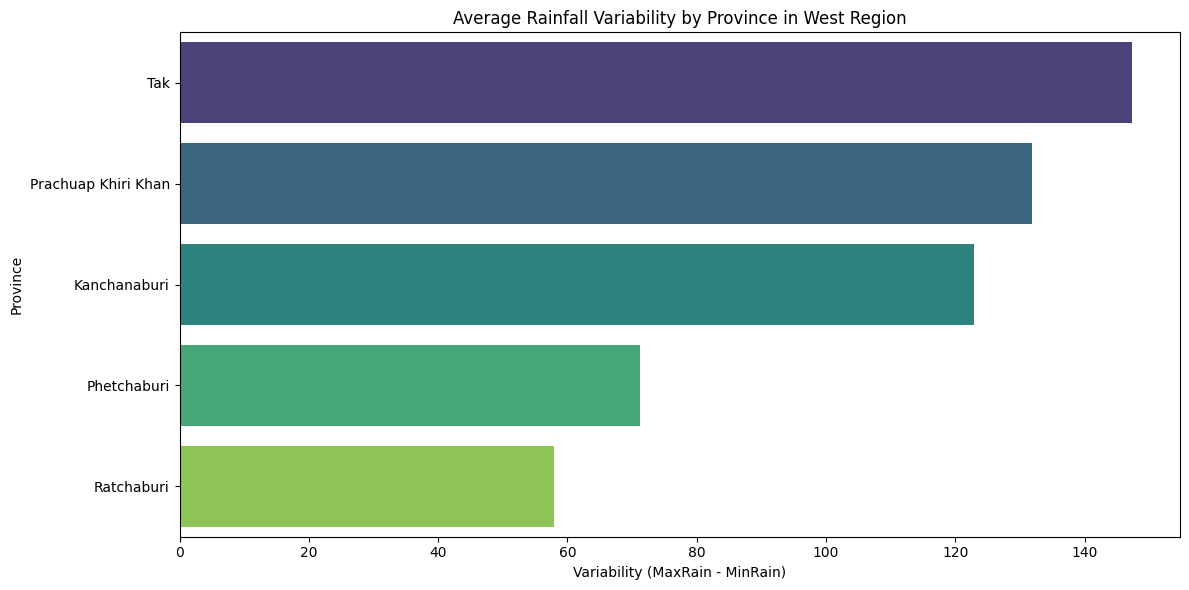

In [ ]:
# ดูความแปรปรวนของปริมาณน้ำฝนเฉลี่ยของแต่ละจังหวัดเปรียบเทียบกันในแต่ละภาค

# Group by region and province to get the average rainfall variability per province
province_variability_region = df.groupby(['REGION', 'PROV_ENG'])['Variability'].mean().reset_index()

# Iterate through each region and create a bar plot
regions = province_variability_region['REGION'].unique()

for region in regions:
    if pd.notnull(region): # Skip NaN region
        region_data = province_variability_region[province_variability_region['REGION'] == region].sort_values('Variability', ascending=False)

        plt.figure(figsize=(12, 6))
        sns.barplot(data=region_data, x='Variability', y='PROV_ENG', palette='viridis')
        plt.title(f'Average Rainfall Variability by Province in {region} Region')
        plt.xlabel("Variability (MaxRain - MinRain)")
        plt.ylabel("Province")
        plt.tight_layout()
        plt.show()

# Export summary for Power BI

In [ ]:
df.to_csv("rain_data.csv", index=False)